## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 기준금리 변경이력 검증 EDA

`BOK_기준금리_변경이력.csv` — **원자료가 정상인가**

앞선 패널 파일들과 구조가 다르다. 이건 **사건 기록(event log)** 이다.
행 하나가 "이 날짜에 금리가 이 값으로 바뀌었다"를 뜻하며,
변경이 없는 기간은 아예 행이 없다.

그래서 검증 항목도 달라진다.

| 단계 | 질문 |
|---|---|
| 0 | 이 파일에 무엇이 들어있는가 |
| 1 | 시간축이 온전한가 (정렬·중복·미래 날짜) |
| 2 | 금리 값이 제도적으로 가능한가 (0.25%p 배수 등) |
| 3 | 변동 패턴에 이상한 기록이 있는가 |
| 4 | 알려진 통화정책 사건과 맞는가 |
| 5 | 파생 계열(연말·연평균·동결기간)이 제대로 만들어지는가 |

## 준비

In [2]:
import pandas as pd, numpy as np, warnings
import matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
          "Pretendard", "Noto Sans CJK KR", "Noto Sans CJK JP"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        print(f"폰트: {f}")
        break
    except Exception:
        continue
mpl.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 100,
                     "axes.grid": True, "grid.alpha": .18,
                     "axes.spines.top": False, "axes.spines.right": False})

INK, WARN, OK, GREY = "#16202B", "#C1682E", "#2E6B5E", "#98A2AA"

def ok_bad(cond, a, b):
    display(Markdown(f"**{'✅ 정상' if cond else '⚠️ 확인필요'}** — {a if cond else b}"))

def paint(df, col="판정", good="정상"):
    styler = df.style
    fn = (lambda x: "background-color:#E4EFEB;color:#1F6152" if x == good
                    else "background-color:#F6E7E4;color:#8E3226")
    # pandas 2.1+ 는 Styler.map, 그 이전 버전은 Styler.applymap 사용
    if hasattr(styler, "map"):
        return styler.map(fn, subset=[col])
    return styler.applymap(fn, subset=[col])

폰트: Malgun Gothic


In [3]:
d = pd.read_csv(str(RAW / "BOK 기준금리 데이터" / "BOK_기준금리_변경이력.csv"), encoding="utf-8-sig")
d["변경일자"] = pd.to_datetime(d["변경일자"], errors="coerce")
d = d.sort_values("변경일자").reset_index(drop=True)
d["변동폭"] = d["기준금리"].diff()

TODAY = pd.Timestamp.today().normalize()
print(f"{len(d)}행 × {d.shape[1]}열")
print(f"기간: {d['변경일자'].min():%Y-%m-%d} ~ {d['변경일자'].max():%Y-%m-%d}")
d.head(5)

61행 × 3열
기간: 1999-05-06 ~ 2026-08-27


,변경일자,기준금리,변동폭
0,1999-05-06,4.75,NaN
1,2000-02-10,5.00,0.25
2,2000-10-05,5.25,0.25
3,2001-02-08,5.00,-0.25
4,2001-07-05,4.75,-0.25


---
## 0단계 · 기본 구조

사건 기록이므로 "행 수 = 금리 변경 횟수"다. 27년간 62회 변경.

In [4]:
span = (d["변경일자"].max() - d["변경일자"].min()).days / 365.25
display(Markdown(f"""
- 변경 기록 **{len(d)}회**
- 관측 기간 **{span:.1f}년** ({d['변경일자'].min():%Y-%m} ~ {d['변경일자'].max():%Y-%m})
- 평균 **{span*12/len(d):.1f}개월**마다 한 번 변경
- 금리 범위 **{d['기준금리'].min():.2f}% ~ {d['기준금리'].max():.2f}%**
"""))

display(d.describe().T.round(3))

display(Markdown("### 자료형"))
display(d.dtypes.rename("dtype").to_frame().T)

ok_bad(d["변경일자"].isna().sum() == 0, "날짜 파싱 실패 0건",
       f"날짜 파싱 실패 {d['변경일자'].isna().sum()}건")
ok_bad(d["기준금리"].isna().sum() == 0, "금리 결측 0건",
       f"금리 결측 {d['기준금리'].isna().sum()}건")


- 변경 기록 **61회**
- 관측 기간 **27.3년** (1999-05 ~ 2026-08)
- 평균 **5.4개월**마다 한 번 변경
- 금리 범위 **0.50% ~ 5.25%**


,count,mean,min,25%,50%,75%,max,std
변경일자,61,2013-01-27 08:39:20.655737,1999-05-06 00:00:00,2006-06-08 00:00:00,2011-06-10 00:00:00,2021-08-26 00:00:00,2026-08-27 00:00:00,NaN
기준금리,61.0,3.012295,0.5,2.0,3.0,4.0,5.25,1.284869
변동폭,60.0,-0.029167,-1.0,-0.25,0.0,0.25,0.5,0.32577


### 자료형

,변경일자,기준금리,변동폭
dtype,datetime64[us],float64,float64


**✅ 정상** — 날짜 파싱 실패 0건

**✅ 정상** — 금리 결측 0건

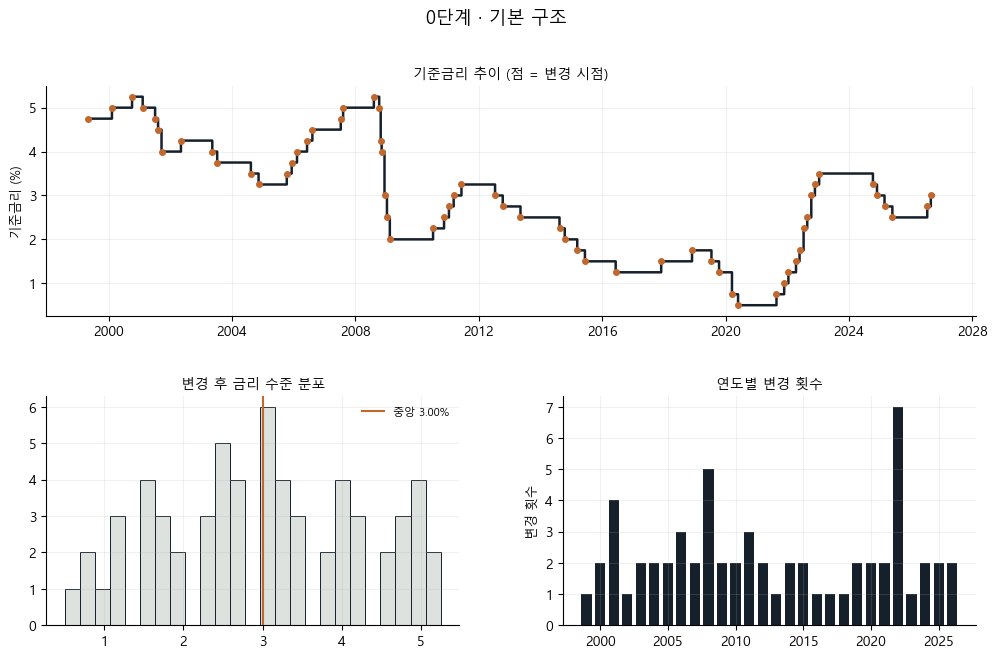

In [5]:
# 일별 계열로 확장 (계단 함수)
idx = pd.date_range(d["변경일자"].min(), TODAY, freq="D")
daily = pd.Series(np.nan, index=idx)
for _, r in d.iterrows():
    daily.loc[r["변경일자"]] = r["기준금리"]
daily = daily.ffill()

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, :])
ax.step(daily.index, daily.values, where="post", lw=1.8, color=INK)
ax.scatter(d["변경일자"], d["기준금리"], s=16, color=WARN, zorder=3)
ax.set_ylabel("기준금리 (%)", fontsize=9)
ax.set_title("기준금리 추이 (점 = 변경 시점)", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
ax.hist(d["기준금리"], bins=25, color="#DDE2DE", edgecolor=INK, linewidth=.7)
ax.axvline(d["기준금리"].median(), color=WARN, lw=1.5,
           label=f"중앙 {d['기준금리'].median():.2f}%")
ax.legend(frameon=False, fontsize=8)
ax.set_title("변경 후 금리 수준 분포", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
cnt = d.groupby(d["변경일자"].dt.year).size()
ax.bar(cnt.index, cnt.values, color=INK, width=.75)
ax.set_ylabel("변경 횟수", fontsize=9)
ax.set_title("연도별 변경 횟수", fontsize=10)

plt.suptitle("0단계 · 기본 구조", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 1단계 · 시간축 무결성

사건 기록은 **날짜가 키**다. 중복·역순·미래 날짜가 있으면
계단 함수로 확장할 때 값이 어긋난다.

In [6]:
raw = pd.read_csv(str(RAW / "BOK 기준금리 데이터" / "BOK_기준금리_변경이력.csv"), encoding="utf-8-sig")
raw["변경일자"] = pd.to_datetime(raw["변경일자"], errors="coerce")

rows = [
    ("날짜 파싱 실패", int(raw["변경일자"].isna().sum())),
    ("날짜 중복", int(raw["변경일자"].duplicated().sum())),
    ("원본이 시간순 정렬 아님", int(not raw["변경일자"].is_monotonic_increasing)),
    ("미래 날짜", int((raw["변경일자"] > TODAY).sum())),
    ("같은 날 금리 둘", int(raw.groupby("변경일자")["기준금리"].nunique().gt(1).sum())),
]
R1 = pd.DataFrame(rows, columns=["점검", "건수"])
R1["판정"] = np.where(R1["건수"] == 0, "정상", "확인필요")
display(paint(R1))

for lab, n in rows:
    ok_bad(n == 0, f"{lab} 없음", f"{lab} {n}건")

gap = d["변경일자"].diff().dt.days.dropna()
display(Markdown("### 변경 간격 (일)"))
display(gap.describe(percentiles=[.25, .5, .75, .95]).round(1).to_frame().T)

display(Markdown("### 가장 짧은 간격 5건 — 연속 인상/인하 구간"))
tmp = d.assign(간격일=d["변경일자"].diff().dt.days)
display(tmp.nsmallest(5, "간격일")[["변경일자", "기준금리", "변동폭", "간격일"]]
        .reset_index(drop=True))

,점검,건수,판정
0,날짜 파싱 실패,0,정상
1,날짜 중복,0,정상
2,원본이 시간순 정렬 아님,0,정상
3,미래 날짜,0,정상
4,같은 날 금리 둘,0,정상


**✅ 정상** — 날짜 파싱 실패 없음

**✅ 정상** — 날짜 중복 없음

**✅ 정상** — 원본이 시간순 정렬 아님 없음

**✅ 정상** — 미래 날짜 없음

**✅ 정상** — 같은 날 금리 둘 없음

### 변경 간격 (일)

,count,mean,std,min,25%,50%,75%,95%,max
변경일자,60.0,166.2,159.6,11.0,49.5,91.0,248.5,464.5,637.0


### 가장 짧은 간격 5건 — 연속 인상/인하 구간

,변경일자,기준금리,변동폭,간격일
0,2008-11-07,4.00,-0.25,11.0
1,2008-10-27,4.25,-0.75,18.0
2,2007-08-09,5.00,0.25,28.0
3,2009-01-09,2.50,-0.50,29.0
4,2008-12-11,3.00,-1.00,34.0


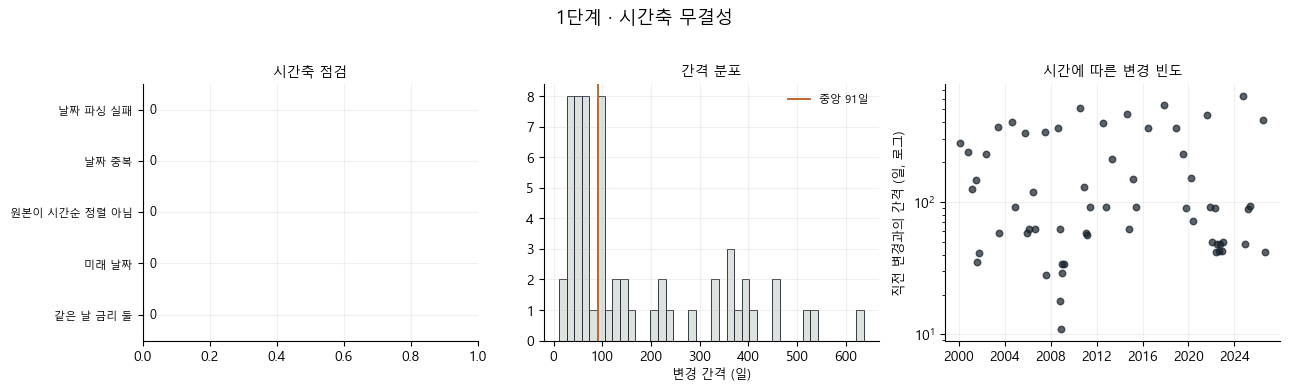

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.barh(R1["점검"][::-1], R1["건수"][::-1],
        color=[OK if v == 0 else WARN for v in R1["건수"][::-1]], height=.55)
ax.set_xlim(0, max(1, R1["건수"].max()*1.3))
for i, v in enumerate(R1["건수"][::-1]):
    ax.text(v + .02, i, str(v), va="center", fontsize=9)
ax.set_title("시간축 점검", fontsize=10); ax.tick_params(axis="y", labelsize=8)

ax = axes[1]
ax.hist(gap, bins=40, color="#DDE2DE", edgecolor=INK, linewidth=.6)
ax.axvline(gap.median(), color=WARN, lw=1.4, label=f"중앙 {gap.median():.0f}일")
ax.legend(frameon=False, fontsize=8)
ax.set_xlabel("변경 간격 (일)", fontsize=9)
ax.set_title("간격 분포", fontsize=10)

ax = axes[2]
ax.scatter(d["변경일자"], d["변경일자"].diff().dt.days, s=22, color=INK, alpha=.7)
ax.set_yscale("log"); ax.set_ylabel("직전 변경과의 간격 (일, 로그)", fontsize=9)
ax.set_title("시간에 따른 변경 빈도", fontsize=10)

plt.suptitle("1단계 · 시간축 무결성", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 2단계 · 값의 제도적 타당성

금통위는 관례적으로 **0.25%p 단위**로 조정한다.
배수가 아니거나 변동폭이 0인 기록은 입력 오류일 수 있다.

In [8]:
step = (d["변동폭"].dropna()*100).round().astype(int)
non25 = step[step % 25 != 0]

rows = [
    ("금리 음수", int((d["기준금리"] < 0).sum())),
    ("금리 0", int((d["기준금리"] == 0).sum())),
    ("금리 10% 초과", int((d["기준금리"] > 10).sum())),
    ("변동폭 0 (무변화 기록)", int((d["변동폭"] == 0).sum())),
    ("0.25%p 배수 아님", int(len(non25))),
]
R2 = pd.DataFrame(rows, columns=["점검", "건수"])
R2["판정"] = np.where(R2["건수"] == 0, "정상", "확인필요")
display(paint(R2))

for lab, n in rows:
    ok_bad(n == 0, f"{lab} 없음", f"{lab} {n}건")

display(Markdown("### 변동폭 분포"))
vc = d["변동폭"].value_counts().sort_index()
T = vc.rename("횟수").to_frame()
T["방향"] = np.where(T.index > 0, "인상", "인하")
T["0.25 배수"] = ["O" if round(i*100) % 25 == 0 else "X" for i in T.index]
display(T.T)

,점검,건수,판정
0,금리 음수,0,정상
1,금리 0,0,정상
2,금리 10% 초과,0,정상
3,변동폭 0 (무변화 기록),0,정상
4,0.25%p 배수 아님,0,정상


**✅ 정상** — 금리 음수 없음

**✅ 정상** — 금리 0 없음

**✅ 정상** — 금리 10% 초과 없음

**✅ 정상** — 변동폭 0 (무변화 기록) 없음

**✅ 정상** — 0.25%p 배수 아님 없음

### 변동폭 분포

변동폭,-1.00,-0.75,-0.50,-0.25,0.25,0.50
횟수,1,1,4,24,28,2
방향,인하,인하,인하,인하,인상,인상
0.25 배수,O,O,O,O,O,O


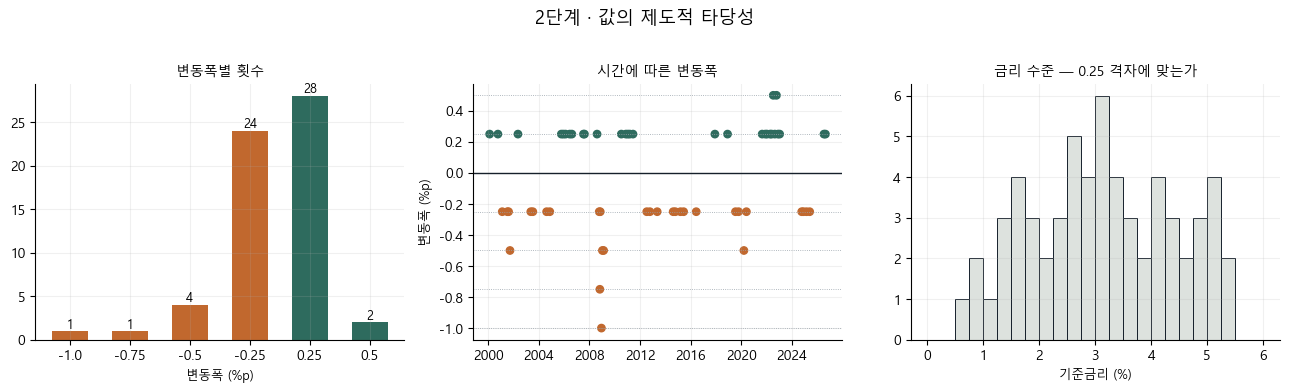

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.bar(vc.index.astype(str), vc.values, width=.6,
       color=[OK if i > 0 else WARN for i in vc.index])
for i, v in enumerate(vc.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("변동폭 (%p)", fontsize=9)
ax.set_title("변동폭별 횟수", fontsize=10)

ax = axes[1]
ax.scatter(d["변경일자"], d["변동폭"], s=28,
           color=[OK if v > 0 else WARN for v in d["변동폭"].fillna(0)])
ax.axhline(0, color=INK, lw=1)
for y in [-1, -.75, -.5, -.25, .25, .5]:
    ax.axhline(y, ls=":", lw=.6, color=GREY)
ax.set_ylabel("변동폭 (%p)", fontsize=9)
ax.set_title("시간에 따른 변동폭", fontsize=10)

ax = axes[2]
ax.hist(d["기준금리"], bins=np.arange(0, 6.1, .25),
        color="#DDE2DE", edgecolor=INK, linewidth=.7)
ax.set_xlabel("기준금리 (%)", fontsize=9)
ax.set_title("금리 수준 — 0.25 격자에 맞는가", fontsize=10)

plt.suptitle("2단계 · 값의 제도적 타당성", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 3단계 · 변동 패턴 이상치

두 가지를 본다.

1. **그 시기 기준으로 유난히 큰 변동** — 위기 대응이면 정상, 아니면 의심
2. **방향 반전** — 올렸다가 곧 내리는 기록은 드물다

In [10]:
d["방향"] = np.sign(d["변동폭"])
d["다음방향"] = d["방향"].shift(-1)
d["다음까지_개월"] = (d["변경일자"].shift(-1) - d["변경일자"]).dt.days / 30.44

# 반전: 방향이 바뀌고 그 간격이 12개월 이내
rev = d[(d["방향"] != 0) & (d["다음방향"] != 0) &
        (d["방향"] != d["다음방향"]) & (d["다음까지_개월"] <= 12)].copy()
rev["다음 변동폭"] = d["변동폭"].shift(-1)[rev.index]
rev["다음 일자"] = d["변경일자"].shift(-1)[rev.index]

display(Markdown(f"### 12개월 이내 방향 반전 — {len(rev)}건"))
display(rev[["변경일자", "기준금리", "변동폭", "다음 일자", "다음 변동폭", "다음까지_개월"]]
        .round(2).reset_index(drop=True))

# 큰 변동 (절대값 0.5%p 이상)
big = d[d["변동폭"].abs() >= .5]
display(Markdown(f"### 0.5%p 이상 변동 — {len(big)}건"))
display(big[["변경일자", "기준금리", "변동폭"]].reset_index(drop=True))

crisis = ["2008", "2009", "2020"]
big_out = big[~big["변경일자"].dt.year.astype(str).isin(crisis)]
ok_bad(len(big_out) == 0,
       "큰 변동이 모두 위기 연도(2008·2009·2020)에 발생",
       f"위기 연도 밖의 큰 변동 {len(big_out)}건 — 아래 표 확인")
if len(big_out):
    display(big_out[["변경일자", "기준금리", "변동폭"]].reset_index(drop=True))

### 12개월 이내 방향 반전 — 6건

,변경일자,기준금리,변동폭,다음 일자,다음 변동폭,다음까지_개월
0,1999-05-06,4.75,NaN,2000-02-10,0.25,9.20
1,2000-10-05,5.25,0.25,2001-02-08,-0.25,4.14
2,2001-09-19,4.00,-0.50,2002-05-07,0.25,7.56
3,2004-11-11,3.25,-0.25,2005-10-11,0.25,10.97
4,2008-08-07,5.25,0.25,2008-10-09,-0.25,2.07
5,2018-11-30,1.75,0.25,2019-07-18,-0.25,7.56


### 0.5%p 이상 변동 — 8건

,변경일자,기준금리,변동폭
0,2001-09-19,4.00,-0.50
1,2008-10-27,4.25,-0.75
2,2008-12-11,3.00,-1.00
3,2009-01-09,2.50,-0.50
4,2009-02-12,2.00,-0.50
5,2020-03-17,0.75,-0.50
6,2022-07-13,2.25,0.50
7,2022-10-12,3.00,0.50


**⚠️ 확인필요** — 위기 연도 밖의 큰 변동 3건 — 아래 표 확인

,변경일자,기준금리,변동폭
0,2001-09-19,4.00,-0.5
1,2022-07-13,2.25,0.5
2,2022-10-12,3.00,0.5


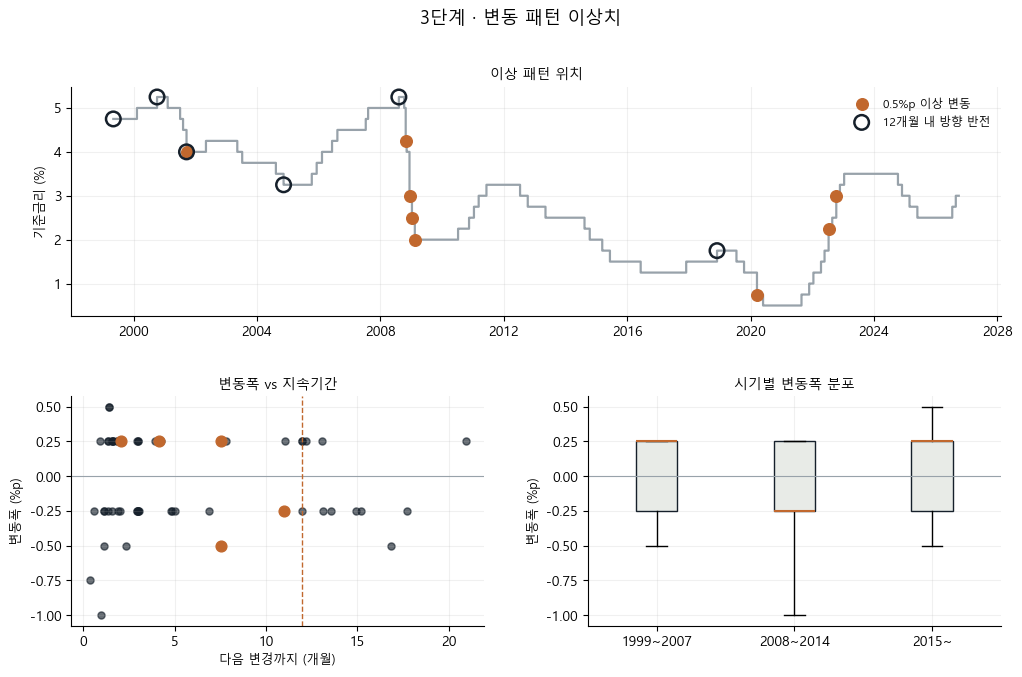

In [11]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, :])
ax.step(daily.index, daily.values, where="post", lw=1.6, color=GREY)
ax.scatter(big["변경일자"], big["기준금리"], s=70, color=WARN,
           zorder=4, label="0.5%p 이상 변동")
if len(rev):
    ax.scatter(rev["변경일자"], rev["기준금리"], s=110, facecolors="none",
               edgecolors=INK, lw=1.8, zorder=5, label="12개월 내 방향 반전")
ax.legend(frameon=False, fontsize=8.5)
ax.set_ylabel("기준금리 (%)", fontsize=9)
ax.set_title("이상 패턴 위치", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
ax.scatter(d["다음까지_개월"], d["변동폭"], s=26, color=INK, alpha=.65)
if len(rev):
    ax.scatter(rev["다음까지_개월"], rev["변동폭"], s=60, color=WARN, zorder=3)
ax.axhline(0, color=GREY, lw=.8); ax.axvline(12, ls="--", lw=1, color=WARN)
ax.set_xlabel("다음 변경까지 (개월)", fontsize=9)
ax.set_ylabel("변동폭 (%p)", fontsize=9)
ax.set_title("변동폭 vs 지속기간", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
era = d.dropna(subset=["변동폭"]).copy()
era["시기"] = pd.cut(era["변경일자"].dt.year,
                   [1998, 2007, 2014, 2030],
                   labels=["1999~2007", "2008~2014", "2015~"])
ax.boxplot([era[era["시기"] == s]["변동폭"].dropna() for s in era["시기"].cat.categories],
           labels=list(era["시기"].cat.categories), patch_artist=True,
           boxprops=dict(facecolor="#E8EBE7", edgecolor=INK),
           medianprops=dict(color=WARN, lw=1.5))
ax.axhline(0, color=GREY, lw=.8)
ax.set_ylabel("변동폭 (%p)", fontsize=9)
ax.set_title("시기별 변동폭 분포", fontsize=10)

plt.suptitle("3단계 · 변동 패턴 이상치", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 4단계 · 외부 사건 정합성

알려진 통화정책 국면과 기록이 맞는지 본다.

In [12]:
events = [
    ("2008-08~2008-12", "글로벌 금융위기 — 급격한 인하", 2008, 2008),
    ("2009-01~2009-02", "위기 대응 추가 인하", 2009, 2009),
    ("2010-07~2011-06", "위기 후 정상화 인상", 2010, 2011),
    ("2020-03~2020-05", "코로나 — 사상 최저", 2020, 2020),
    ("2021-08~2023-01", "인플레 대응 긴축", 2021, 2023),
    ("2024-10~2025-05", "인하 전환", 2024, 2025),
]
rows = []
for lab, desc, y0, y1 in events:
    sub = d[(d["변경일자"].dt.year >= y0) & (d["변경일자"].dt.year <= y1)]
    if len(sub) == 0:
        rows.append({"구간": lab, "사건": desc, "변경횟수": 0,
                     "순변동": np.nan, "판정": "기록없음"})
        continue
    prev = d[d["변경일자"] < sub["변경일자"].iloc[0]]["기준금리"]
    start = prev.iloc[-1] if len(prev) else sub["기준금리"].iloc[0]
    net = sub["기준금리"].iloc[-1] - start
    rows.append({"구간": lab, "사건": desc, "변경횟수": len(sub),
                 "순변동": round(net, 2),
                 "판정": "정상" if len(sub) > 0 else "기록없음"})
R4 = pd.DataFrame(rows)
display(paint(R4))

ok_bad(R4["변경횟수"].gt(0).all(), "알려진 모든 국면에 기록 존재", "누락된 국면 있음")

display(Markdown("### 긴축·완화 사이클 자동 탐지"))
cyc, cur = [], None
for i in range(1, len(d)):
    dr = "인상" if d["기준금리"].iloc[i] > d["기준금리"].iloc[i-1] else "인하"
    if cur is None or cur["방향"] != dr:
        if cur: cyc.append(cur)
        cur = {"방향": dr, "시작": d["변경일자"].iloc[i-1],
               "시작금리": d["기준금리"].iloc[i-1],
               "끝": d["변경일자"].iloc[i], "끝금리": d["기준금리"].iloc[i]}
    else:
        cur["끝"] = d["변경일자"].iloc[i]; cur["끝금리"] = d["기준금리"].iloc[i]
cyc.append(cur)

CY = pd.DataFrame(cyc)
CY["폭"] = (CY["끝금리"] - CY["시작금리"]).round(2)
CY["기간(월)"] = ((CY["끝"] - CY["시작"]).dt.days/30.44).round(1)
CY = CY[CY["폭"].abs() >= .5]
CY["시작"] = CY["시작"].dt.strftime("%Y-%m"); CY["끝"] = CY["끝"].dt.strftime("%Y-%m")
display(CY[["방향", "시작", "끝", "시작금리", "끝금리", "폭", "기간(월)"]]
        .reset_index(drop=True))

,구간,사건,변경횟수,순변동,판정
0,2008-08~2008-12,글로벌 금융위기 — 급격한 인하,5,-2.000000,정상
1,2009-01~2009-02,위기 대응 추가 인하,2,-1.000000,정상
2,2010-07~2011-06,위기 후 정상화 인상,5,1.250000,정상
3,2020-03~2020-05,코로나 — 사상 최저,2,-0.750000,정상
4,2021-08~2023-01,인플레 대응 긴축,10,3.000000,정상
5,2024-10~2025-05,인하 전환,4,-1.000000,정상


**✅ 정상** — 알려진 모든 국면에 기록 존재

### 긴축·완화 사이클 자동 탐지

,방향,시작,끝,시작금리,끝금리,폭,기간(월)
0,인상,1999-05,2000-10,4.75,5.25,0.50,17.0
1,인하,2000-10,2001-09,5.25,4.00,-1.25,11.5
2,인하,2002-05,2004-11,4.25,3.25,-1.00,30.2
3,인상,2004-11,2008-08,3.25,5.25,2.00,44.8
4,인하,2008-08,2009-02,5.25,2.00,-3.25,6.2
5,인상,2009-02,2011-06,2.00,3.25,1.25,27.9
6,인하,2011-06,2016-06,3.25,1.25,-2.00,60.0
7,인상,2016-06,2018-11,1.25,1.75,0.50,29.7
8,인하,2018-11,2020-05,1.75,0.50,-1.25,17.9
9,인상,2020-05,2023-01,0.50,3.50,3.00,31.5


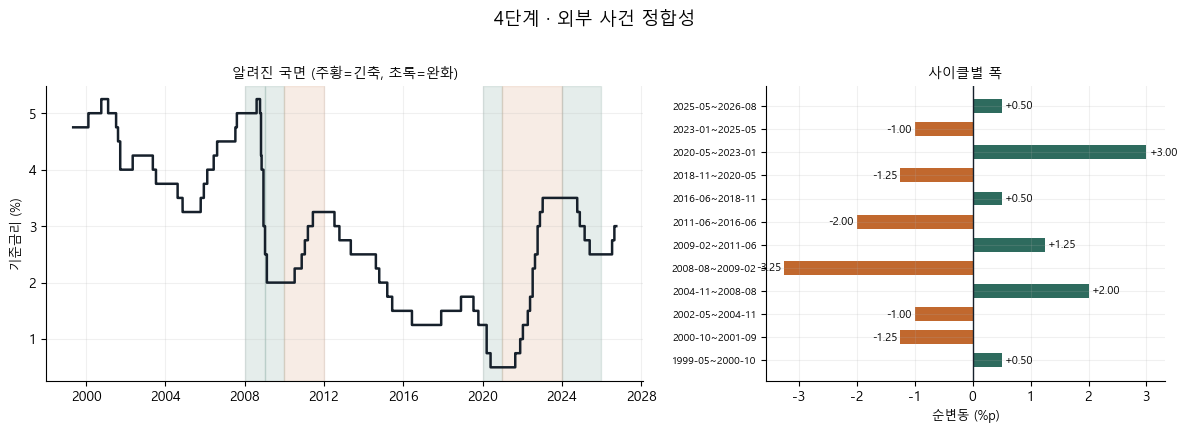

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2),
                         gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
ax.step(daily.index, daily.values, where="post", lw=1.8, color=INK)
for lab, desc, y0, y1 in events:
    ax.axvspan(pd.Timestamp(f"{y0}-01-01"), pd.Timestamp(f"{y1}-12-31"),
               color=WARN if "긴축" in desc or "인상" in desc else OK, alpha=.12)
ax.set_ylabel("기준금리 (%)", fontsize=9)
ax.set_title("알려진 국면 (주황=긴축, 초록=완화)", fontsize=10)

ax = axes[1]
y = np.arange(len(CY))
ax.barh(y, CY["폭"], height=.6,
        color=[OK if p > 0 else WARN for p in CY["폭"]])
ax.set_yticks(y)
ax.set_yticklabels([f"{s}~{e}" for s, e in zip(CY["시작"], CY["끝"])], fontsize=7.5)
ax.axvline(0, color=INK, lw=1)
for i, v in enumerate(CY["폭"]):
    ax.text(v + (.05 if v > 0 else -.05), i, f"{v:+.2f}",
            va="center", ha="left" if v > 0 else "right", fontsize=8)
ax.set_xlabel("순변동 (%p)", fontsize=9)
ax.set_title("사이클별 폭", fontsize=10)

plt.suptitle("4단계 · 외부 사건 정합성", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 5단계 · 파생 계열

연간 패널에 붙이려면 **연말값**과 **연평균**을 만들어야 한다.
둘은 크게 다를 수 있으므로 어느 쪽을 쓸지 정해야 한다.

In [14]:
g = daily.groupby(daily.index.year)
Y = pd.DataFrame({
    "연말금리": g.last(),
    "연평균":   g.mean().round(3),
    "연중최고": g.max(),
    "연중최저": g.min(),
})
Y.index.name = "연도"
Y["전년말대비"] = Y["연말금리"].diff().round(2)
Y["변경횟수"] = d.groupby(d["변경일자"].dt.year).size().reindex(Y.index).fillna(0).astype(int)
Y["국면"] = np.select([Y["전년말대비"] > .1, Y["전년말대비"] < -.1],
                     ["인상", "인하"], "동결")

display(Markdown("### 최근 12년"))
display(Y.tail(12))

gapY = (Y["연말금리"] - Y["연평균"]).abs()
worst = gapY.idxmax()
display(Markdown(f"""
### 연말값 vs 연평균

가장 크게 갈리는 해는 **{worst}년** — 연말 {Y.loc[worst,'연말금리']:.2f}% vs
연평균 {Y.loc[worst,'연평균']:.2f}% (차이 {gapY.max():.2f}%p),
그해 **{Y.loc[worst,'변경횟수']}회** 변경했기 때문이다.

연간 재무데이터(ICR 등)와 대응시킬 때는 **연평균**이 개념적으로 맞다.
1년간 누적된 이자비용은 연중 평균 금리 환경을 반영하기 때문이다.
"""))

hold = d.assign(다음=d["변경일자"].shift(-1).fillna(TODAY))
hold["유지개월"] = ((hold["다음"] - hold["변경일자"]).dt.days/30.44).round(1)
display(Markdown("### 동결 기간 상위 8 — 평시 구간 후보"))
display(hold.nlargest(8, "유지개월")[["변경일자", "다음", "기준금리", "유지개월"]]
        .assign(변경일자=lambda x: x["변경일자"].dt.strftime("%Y-%m"),
                다음=lambda x: x["다음"].dt.strftime("%Y-%m"))
        .reset_index(drop=True))

### 최근 12년

,연말금리,연평균,연중최고,연중최저,전년말대비,변경횟수,국면
연도,,,,,,,
2015,1.50,1.658,2.00,1.50,-0.50,2,인하
2016,1.25,1.359,1.50,1.25,-0.25,1,인하
2017,1.50,1.272,1.50,1.25,0.25,1,인상
2018,1.75,1.522,1.75,1.50,0.25,1,인상
2019,1.25,1.583,1.75,1.25,-0.50,2,인하
2020,0.50,0.705,1.25,0.50,-0.75,2,인하
2021,1.00,0.613,1.00,0.50,0.50,2,인상
2022,3.25,2.032,3.25,1.00,2.25,7,인상
2023,3.50,3.492,3.50,3.25,0.25,1,인상



### 연말값 vs 연평균

가장 크게 갈리는 해는 **2008년** — 연말 3.00% vs
연평균 4.81% (차이 1.81%p),
그해 **5회** 변경했기 때문이다.

연간 재무데이터(ICR 등)와 대응시킬 때는 **연평균**이 개념적으로 맞다.
1년간 누적된 이자비용은 연중 평균 금리 환경을 반영하기 때문이다.


### 동결 기간 상위 8 — 평시 구간 후보

,변경일자,다음,기준금리,유지개월
0,2023-01,2024-10,3.50,20.9
1,2016-06,2017-11,1.25,17.7
2,2009-02,2010-07,2.00,16.8
3,2013-05,2014-08,2.50,15.2
4,2020-05,2021-08,0.50,14.9
5,2025-05,2026-07,2.50,13.6
6,2003-07,2004-08,3.75,13.1
7,2011-06,2012-07,3.25,13.1


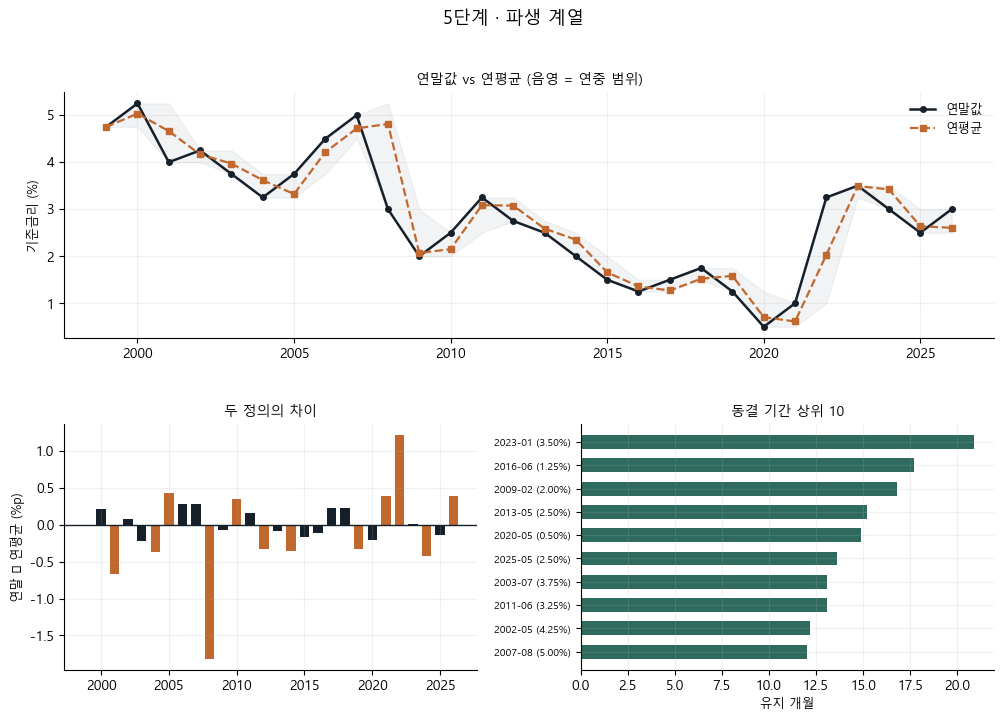

In [15]:
fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, :])
ax.plot(Y.index, Y["연말금리"], "o-", lw=1.8, color=INK, ms=4, label="연말값")
ax.plot(Y.index, Y["연평균"], "s--", lw=1.6, color=WARN, ms=4, label="연평균")
ax.fill_between(Y.index, Y["연중최저"], Y["연중최고"], alpha=.12, color=GREY)
ax.legend(frameon=False, fontsize=9)
ax.set_ylabel("기준금리 (%)", fontsize=9)
ax.set_title("연말값 vs 연평균 (음영 = 연중 범위)", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
ax.bar(Y.index, (Y["연말금리"] - Y["연평균"]), width=.7,
       color=[WARN if abs(v) > .3 else INK for v in (Y["연말금리"]-Y["연평균"])])
ax.axhline(0, color=INK, lw=1)
ax.set_ylabel("연말 − 연평균 (%p)", fontsize=9)
ax.set_title("두 정의의 차이", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
h = hold.nlargest(10, "유지개월")
ax.barh(range(len(h)), h["유지개월"], height=.6, color=OK)
ax.set_yticks(range(len(h)))
ax.set_yticklabels([f"{a:%Y-%m} ({b:.2f}%)" for a, b in
                    zip(h["변경일자"], h["기준금리"])][::1], fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel("유지 개월", fontsize=9)
ax.set_title("동결 기간 상위 10", fontsize=10)

plt.suptitle("5단계 · 파생 계열", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 종합

In [16]:
S = pd.DataFrame([
    ("0 기본구조", f"{len(d)}회 변경, {span:.1f}년, 결측 0", "정상"),
    ("1 시간축", "중복·역순·미래 날짜 없음",
     "정상" if R1["건수"].sum() == 0 else "확인필요"),
    ("2 값", f"전부 0.25%p 배수, 변동폭 0 없음",
     "정상" if R2["건수"].sum() == 0 else "확인필요"),
    ("3 패턴", f"0.5%p 이상 {len(big)}건, 12개월 내 반전 {len(rev)}건",
     "정상" if len(big_out) == 0 else "확인필요"),
    ("4 외부", "알려진 국면 모두 기록됨", "정상"),
    ("5 파생", f"연말/연평균 최대 차이 {gapY.max():.2f}%p ({worst}년)", "정상"),
], columns=["단계", "내용", "판정"])
display(paint(S))

display(Markdown(f"""
### 사용 시 주의

1. **연평균을 쓴다** — 연간 ICR과 대응시키려면 연말값이 아니라 연중 평균 금리 환경
2. **1999년 5월 이전은 없다** — 그 이전은 콜금리 목표제라 계열이 단절된다.
   1997 외환위기를 포함하려면 별도 계열이 필요하다
3. **전국 단위 변수라 연도 고정효과에 흡수된다** — 회귀에 단독으로 넣을 수 없고,
   업종별 노출도와 곱해야 식별된다
4. 위 3단계에서 걸린 기록은 원출처(ECOS)와 한 번 대조할 것
"""))

Y.to_csv(INTERIM / "기준금리_연도별.csv", encoding="utf-8-sig")
hold[["변경일자", "기준금리", "변동폭", "유지개월"]].to_csv(
    INTERIM / "기준금리_변경이력_가공.csv", index=False, encoding="utf-8-sig")
print("저장: 기준금리_연도별.csv, 기준금리_변경이력_가공.csv")

,단계,내용,판정
0,0 기본구조,"61회 변경, 27.3년, 결측 0",정상
1,1 시간축,중복·역순·미래 날짜 없음,정상
2,2 값,"전부 0.25%p 배수, 변동폭 0 없음",정상
3,3 패턴,"0.5%p 이상 8건, 12개월 내 반전 6건",확인필요
4,4 외부,알려진 국면 모두 기록됨,정상
5,5 파생,연말/연평균 최대 차이 1.81%p (2008년),정상



### 사용 시 주의

1. **연평균을 쓴다** — 연간 ICR과 대응시키려면 연말값이 아니라 연중 평균 금리 환경
2. **1999년 5월 이전은 없다** — 그 이전은 콜금리 목표제라 계열이 단절된다.
   1997 외환위기를 포함하려면 별도 계열이 필요하다
3. **전국 단위 변수라 연도 고정효과에 흡수된다** — 회귀에 단독으로 넣을 수 없고,
   업종별 노출도와 곱해야 식별된다
4. 위 3단계에서 걸린 기록은 원출처(ECOS)와 한 번 대조할 것


저장: 기준금리_연도별.csv, 기준금리_변경이력_가공.csv
